In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sc_flow.trainer._trainer import FlowTrainer
import matplotlib.pyplot as plt
import optax
# from sc_flow.backends.torch.methods import BaseMethod

In [ ]:
import abc
from typing import Any, Literal
from dataclasses import field as dc_field

from flax.training import train_state
import flax.linen as nn
import jax
import jax.numpy as jnp

from sc_flow._constants import (
    DEFAULT_CONDITION_ENCODER_OUTPUT_DIM,
    DEFAULT_NUM_TIME_FEATURES,
    DEFAULT_SOURCE_ENCODER_OUTPUT_DIM,
    DEFAULT_TIME_FEATURES_MAX_PERIOD,
    DEFAULT_VF_LATENT_STATE_DIM,
    DEFAULT_VF_LATENT_TIME_DIM,
)
from sc_flow._types import ConditioningLayersId, LayersDict, NestedLayersDict, TimeFeaturesId
from sc_flow.backends.jax._types import ArrayLike, MappedArray, TConditioningFn, TTimeFeaturesFn, TVfFn
from sc_flow.backends.jax._utils import make_concatenation_possible
from sc_flow.backends.jax.nn._conditioning_layers import BaseConditioningLayer, get_conditioning_layer
from sc_flow.backends.jax.nn._modules import BaseModule, FunctionalModule
from sc_flow.backends.jax.nn._set_encoder import SetEncoder
from sc_flow.backends.jax.nn._time_features import get_time_features_fn
from sc_flow.backends.jax.nn._utils import init_module_from_dict

__all__ = [
    "BaseVelocityField",
    "MLPUnconditionalVF",
]


class BaseVelocityField(abc.ABC, nn.Module):
    """Base class for neural velocity fields."""

    @abc.abstractmethod
    def _make_vf(
        self,
    ) -> nn.Module:
        """Initializes the neural components of the velocity field."""

    @abc.abstractmethod
    def __call__(
        self,
        t: ArrayLike,
        xt: ArrayLike,
        *args,
        **kwargs,
    ) -> ArrayLike:
        """Performs a forward computation pass on the neural velocity field.

        :param t: The current time index at which the velocity field is computed.
        :type t: class: `~sc_flow.backends.jax._types.ArrayLike`

        :param x: The current state at which the velocity field is computed.
        :type x: class: `~sc_flow.backends.jax._types.ArrayLike`

        :param args: Additional positional arguments used to compute the velocity field.
        :type args: class: `tuple[sc_flow.backends.jax._types.ArrayLike]`
        """

    @abc.abstractmethod
    def get_vf_fn(
        self,
        *args,
        **kwargs,
    ) -> TVfFn:
        """Compiles the velocity field function to be fed to external solvers."""


class MLPUnconditionalVF(BaseVelocityField):
    """Class for MLP-base unconditional neural velocity fields.

    The architecture of unconditional velocity fields is defined as follows:
        * (Optional) Time Featurization. An identity mapping is instantiated otherwise.
        * (Optional) Time MLP Encoder. An identity mapping is instantiated otherwise.
        * (Optional) State MLP Encoder. An identity mapping is instantiated otherwise.
        * Conditioning layer, whereby the state and time information are combined.
        * Velocity Field Decoder ultimately computing the velocity field.


    Initializes the velocity field with the given settings.

    :param state_dim: The dimensionality of the state space where the
        dynamics is defined.
    :type state_dim: class: `int`

    :param encode_state: (Optional) Whether to initilize an :class: `MLP` for
        encoding the states. Defaults to `True`.
    :type encode_state: class: `bool`

    :param encode_time: (Optional) Whether to initilize an :class: `MLP` for
        encoding the time index. Defaults to `True`.
    :type encode_time: class: `bool`

    :param time_features_id: (Optional) The identifier for the chosen time features.
        Could be set to any of the string identifiers for predefined time features,
        specified in :class: `TimeFeaturesId`. Ignored when :param: `time_features_fn`
        is passed as well. Defaults to `None`, in which case no time features are computed
        (i.e.: identity mapping).
    :type time_features_id: class: `TimeFeaturesId | None`

    :param time_features_fn: (Optional) Function defining the custom time featurizer which should accept tensor with
        trailing singleton dimension and expand the trailing dimension to $2K$.The input function is wrapped,
        so that it only need to actually implement the expansion of the trailing dimension.
        When provided, takes precedence over string initialization. Defaults to `None`.
    :type time_features_fn: class: `TTimeFeaturesFn | None`

    :param num_time_features: (Optional) Sets the number of resulting time features, hence it must be even.
        Raises a :class: `ValueError` otherwise. When not provided, it will be set to
        :constant: `sc_flow._constants.DEFAULT_NUM_TIME_FEATURES`. Defaults to `None`.
    :type num_time_features: class: `int | None`

    :param max_period: (Optional) Sets the value of $M$, used for the linear scaling of the time features.
        Only used when :param: `time_features_id` is set to `"torch-cfm"`, ignored otherwise.
        When not provided, it will be set to :constant: `sc_flow._constants.DEFAULT_TIME_FEATURES_MAX_PERIOD`. Defaults to `None`.
    :type max_period: class: `int | None`

    :param time_features_kwargs: (Optional) Keyword arguments used to compile custom time featurizers. Only used when
        initializing time featurizers with :param: `time_features_fn`, ignored otherwise. Defaults to `None`
    :type time_features_kwargs: class: `dict[str, Any] | None`

    :param state_encoder_output_dim: (Optional) The output dimensionality for the state encoder, only used when :param: `encode_state`
        is set to `True`. When `None` it will be set to :constant: `sc_flow._constants.DEFAULT_VF_LATENT_STATE_DIM`.
        Defaults to `None`.
    :type state_encoder_output_dim: class: `int | None`

    :param time_encoder_output_dim: (Optional) The output dimensionality for the time encoder, only used when :param: `encode_time`
        is set to `True`. When `None` it will be set to :constant: `sc_flow._constants.DEFAULT_VF_LATENT_TIME_DIM`.
        Defaults to `None`.
    :type time_encoder_output_dim: class: `int | None`

    :param state_encoder_mlp_kwargs: (Optional) Keyword arguments used for initializing the state encoder. When used, its key-value pairs
        should match the signature of the `__init__` method of the :class: `MLP` class, raise :class: `TypeError` otherwise.
        Only used when :param: `encode_state` is set to `True`. When `None` it will be set to an empty dictionary,
        hence falling back to the default configurations defined directly in :class: `MLP`. Defaults to `None`.
    :type state_encoder_mlp_kwargs: class: `dict[str, Any] | None`

    :param time_encoder_mlp_kwargs: (Optional) Keyword arguments used for initializing the time encoder. When used, its key-value pairs
        should match the signature of the `__init__` method of the :class: `MLP` class, raise :class: `TypeError` otherwise.
        Only used when :param: `encode_time` is set to `True`. When `None` it will be set to an empty dictionary,
        hence falling back to the default configurations defined directly in :class: `MLP`. Defaults to `None`.
    :type time_encoder_mlp_kwargs: class: `dict[str, Any] | None`

    :param vf_decoder_mlp_kwargs: (Optional) Keyword arguments used for initializing the velocity field decoder. Its key-value pairs
        should match the signature of the `__init__` method of the :class: `MLP` class, raise :class: `TypeError` otherwise.
        When `None` it will be set to an empty dictionary, hence falling back to the default configurations
        defined directly in :class: `MLP`. Defaults to `None`.
    :type vf_decoder_mlp_kwargs: class: `dict[str, Any] | None`

    :param conditioning_id: (Optional) String identifier indicating the type of conditioning applied to the states.
        For unconditional velocity fields, the conditioning is only done with respect to the time index.
        Could be set to any of the string identifiers for predefined time features, specified in :class: `ConditioningLayersId`.
        Ignored when :param: `conditioning_fn` is passed as well. Defaults to `None` and, when not provided, it will be set internally set to
        :constant: `sc_flow._constants.DEFAULT_CONDITIONING_LAYER`.
    :type conditioning_id: class: `ConditioningLayersId`

    :param conditioning_fn: (Optional) Callable using for the instantiation of custom conditioning layers.
        When provided, takes precedence over string initialization. Defaults to `None`.
    :type conditioning_fn: class: `TConditioningFn`

    :param conditioning_kwargs: (Optional) Keyword arguments used to initialize the conditioning layer.
        Ignored when the using concatenation based conditioning. When setting :param: `conditioning_id`
        to `"resnet1d"`, it should match the signatures of the `__init__` method of the :class: `Resnet1d` class,
        raise :class: `TypeError` otherwise. Defaults to `None`.
    :type conditioning_kwargs: class: `dict[str, Any]`

    :param condition_encoder_input_layers: Dictionary mapping each perturbation covariate
        identifier to the configurations for their respective input layer.
    :type condition_encoder_input_layers: class: `NestedLayersDict`

    :param condition_encoder_output_dim: The output dimensionality of the set encoder.
    :type condition_encoder_output_dim: class: `int`

    :param condition_encoder_pooling_mode: Identifier for the pooling strategy of conditioning covariates.
        Defaults to `"mean"`.
    :type condition_encoder_pooling_mode: class: `Literal["mean", "sum"]`

    :param condition_encoder_pooling_kwargs: Optional keyword arguments for pooling layer.
        Ignored when pooling is `"mean"` or `"sum"`, defaults to `None`.
    :type condition_encoder_pooling_kwargs: class: `dict[str, Any]`

    :param condition_encoder_covariates_not_pooled: Optional sequence of the perturbation covariate
        identifiers for which the pooling should not be applied. Defaults to `None`.
    :class condition_encoder_covariates_not_pooled: class: `Sequence[int] | None`

    :param condition_encoder_output_layers_kwargs: Dictionary containing the configurations for the output layer.
        Defaults to `None`.
    :type condition_encoder_output_layers_kwargs: class: `LayersDict | None`

    :param source_encoder_mlp_kwargs: (Optional) Keyword arguments used to initialize
        source state encoders when provided. This is needed to retain the information about the
        source states when interpolating between noise and samples from the target distribution.
        Defaults to `None`, in which case no source encoder will be initialized.
    :type source_encoder_mlp_kwargs: class: `LayersDict`

    :param source_encoder_output_dim: (Optional) Output dimensionality for the source state encoder.
        Only used when encoding source states. Defaults to `None`.
    :type source_encoder_output_dim: class: `int`
    """

    state_dim: int
    encode_state: bool = True
    encode_time: bool = True
    time_features_id: TimeFeaturesId | None = None
    time_features_fn: TTimeFeaturesFn | None = None
    num_time_features: int | None = DEFAULT_NUM_TIME_FEATURES
    max_period: int = DEFAULT_TIME_FEATURES_MAX_PERIOD
    time_features_kwargs: dict[str, Any] = dc_field(default_factory=dict)
    state_encoder_output_dim: int = DEFAULT_VF_LATENT_STATE_DIM
    time_encoder_output_dim: int = DEFAULT_VF_LATENT_TIME_DIM
    state_encoder_mlp_kwargs: LayersDict = dc_field(default_factory=dict)
    time_encoder_mlp_kwargs: LayersDict = dc_field(default_factory=dict)
    vf_decoder_mlp_kwargs: LayersDict = dc_field(default_factory=dict)
    conditioning_id: ConditioningLayersId | None = "concat"
    conditioning_fn: TConditioningFn | None = None
    conditioning_kwargs: dict[str, Any] | None = None
    condition_encoder_input_layers: NestedLayersDict | None = None
    condition_encoder_output_dim: int = DEFAULT_CONDITION_ENCODER_OUTPUT_DIM
    condition_encoder_pooling_mode: Literal["mean", "sum"] = "mean"
    condition_encoder_pooling_kwargs: dict[str, Any] = dc_field(default_factory=dict)
    condition_encoder_output_layers_kwargs: LayersDict | None = None
    source_encoder_mlp_kwargs: LayersDict | None = None
    source_encoder_output_dim: int = DEFAULT_SOURCE_ENCODER_OUTPUT_DIM

    def setup(self) -> None:
        """Initialize the network."""
        self.vf = self._make_vf()

    @property
    def use_time_features(self) -> bool:
        """Boolean flag indicating whether time featurization is used for the current velocity field.

        This is the case when either :param: `time_features_id` or :param: `time_features_fn`
        are passed during initialization.
        """
        return (self.time_features_id is not None) or (self.time_features_fn is not None)

    @property
    def use_source_encoder(self) -> bool:
        """Boolean flag indicating whether an MLP should be initialized to encode source states."""
        return self.source_encoder_mlp_kwargs is not None

    @property
    def source_encoder_input_dim(self) -> int:
        """Returns the input dimensionality for the source encoder.

        When not explicitly specified in source_encoder_mlp_kwargs, it will be
        automatically retrieved from state_dim.
        """
        input_dim = self.source_encoder_mlp_kwargs.get("input_dim", None)
        if input_dim is None:
            return self.state_dim
        return input_dim

    @property
    def conditioning_dim(self) -> int | None:
        """Returns the dimensionality for the condition input of the conditioning layers."""
        if self.is_conditional and self.use_source_encoder:
            return self.resolved_condition_encoder_output_dim + self.resolved_source_encoder_output_dim
        elif self.is_conditional and (not self.use_source_encoder):
            return self.resolved_condition_encoder_output_dim
        elif self.use_source_encoder:
            return self.resolved_source_encoder_output_dim
        return None

    def get_num_time_features(
        self,
    ) -> int:
        """Returns the number of time features.

        If no time featurization is used, it will return simply 1 (i.e.: scalar time)
        Otherwise, when the number of time feature is not provided, it will fall back to the default defined in
        :constant: `sc_flow._constants.DEFAULT_NUM_TIME_FEATURES`.
        """
        if not self.use_time_features:
            return 1
        else:
            if self.num_time_features is None:
                return DEFAULT_NUM_TIME_FEATURES
            return self.num_time_features

    def get_encoded_conditions(
        self,
        condition_dict: MappedArray | None,
    ) -> ArrayLike | None:
        """Retrieves the encoded conditions."""
        if self.is_conditional:
            if condition_dict is None:
                msg = "Conditional VFs should take a condition as input, found `None`."
                raise TypeError(msg)
            return self.vf["condition_encoder"](condition_dict)
        return None

    def get_encoded_source(
        self,
        source: ArrayLike | None,
    ) -> ArrayLike | None:
        """Retrieves the encoded source states."""
        if self.use_source_encoder:
            if source is None:
                msg = "When using source encoder a source state should be passed, found `None`."
                raise TypeError(msg)
            return self.vf["source_encoder"](source)
        return None

    def get_conditioning_input(self, encoded_condition: ArrayLike, encoded_source: ArrayLike) -> ArrayLike | None:
        """Retrieves the condition input for the conditioning layers."""
        if encoded_condition is not None and encoded_source is not None:
            return jnp.concatenate(
                (make_concatenation_possible(encoded_condition, encoded_source, -1), encoded_source), dim=-1
            )
        elif encoded_condition is None and encoded_source is not None:
            return encoded_source
        elif encoded_condition is not None and encoded_source is None:
            return encoded_source
        return None

    def _make_time_features(
        self,
    ) -> FunctionalModule:
        """Initializes the time features.

        Wraps a :class: `FunctionalModule` around the function used to compute the time features for
        compatibility with Flax's module system.
        """
        time_features_fn = get_time_features_fn(
            num_time_features=self.get_num_time_features(),
            time_features_id=self.time_features_id,
            time_features_fn=self.time_features_fn,
            max_period=self.max_period,
            time_features_kwargs=self.time_features_kwargs,
        )
        return FunctionalModule(time_features_fn)

    def _make_time_encoder(
        self,
    ) -> BaseModule:
        """Initializes the optional time encoder.

        When :param: `encode_time` is set to `True` it will initialize a :class: `MLP` with the configurations
        specified in :param: `time_encoder_mlp_kwargs`. Returns an identity function wrapper otherwise otherwise.
        """
        if self.encode_time:
            return init_module_from_dict(
                self.time_encoder_mlp_kwargs,
                input_dim=self.get_num_time_features(),
                output_dim=self.time_encoder_output_dim,
            )
        return FunctionalModule(lambda x: x)

    def _make_state_encoder(
        self,
    ) -> BaseModule:
        """Initializes the optional state encoder.

        When :param: `encode_state` is set to `True` it will initialize a :class: `MLP` with the configurations
        specified in :param: `state_encoder_mlp_kwargs`. Returns an identity function wrapper otherwise otherwise.
        """
        if self.encode_state:
            return init_module_from_dict(
                self.state_encoder_mlp_kwargs,
                input_dim=self.state_dim,
                output_dim=self.state_encoder_output_dim,
            )
        return FunctionalModule(lambda x: x)

    def _make_conditioning_layer(
        self,
    ) -> BaseConditioningLayer:
        """Initializes the conditioning layer according to the configurations specified during initialization."""
        return get_conditioning_layer(
            self.state_encoder_output_dim if self.encode_state else self.state_dim,
            self.time_encoder_output_dim if self.encode_time else self.get_num_time_features(),
            latent_condition_dim=self.conditioning_dim,
            conditioning_id=self.conditioning_id,
            conditioning_fn=self.conditioning_fn,
            conditioning_kwargs=self.conditioning_kwargs,
        )

    def _make_condition_encoder(
        self,
    ) -> BaseModule:
        """Initializes the condition encoder when the required settings are specified."""
        if not self.is_conditional:
            msg = (
                "To initialize the condition encoder you have to pass"
                "the `condition_encoder_input_layers` argument, `None` found."
            )
            raise TypeError(msg)
        return SetEncoder(
            self.condition_encoder_input_layers,
            self.condition_encoder_output_dim,
            pooling_mode=self.condition_encoder_pooling_mode,
            pooling_kwargs=self.condition_encoder_pooling_kwargs,
            output_layers_kwargs=self.condition_encoder_output_layers_kwargs,
        )

    def _make_vf_decoder(
        self,
        decoder_input_dim: int,
    ) -> BaseModule:
        """Initializes the velocity field decoder.

        It will initialize a :class: `MLP` with the configurations specified in :param: `vf_decoder_mlp_kwargs`.
        """
        return init_module_from_dict(
            self.vf_decoder_mlp_kwargs,
            input_dim=decoder_input_dim,
            output_dim=self.state_dim,
        )

    def _make_source_encoder(
        self,
    ) -> BaseModule:
        """Initializes the source state encoder when the required settings are passed."""
        if not self.use_source_encoder:
            msg = (
                "To initialize the source encoder you have to pass"
                "the `source_encoder_mlp_kwargs` argument, `None` found."
            )
            raise TypeError(msg)

        return init_module_from_dict(
            self.source_encoder_mlp_kwargs,
            input_dim=self.source_encoder_input_dim,
            output_dim=self.source_encoder_output_dim,
        )

    def _make_vf(
        self,
    ) -> nn.Module:
        """Initializes the neural components of the velocity field.

        This is done by calling the `self._make_*` methods defined above.
        """
        modules = {
            "time_features": self._make_time_features(),
            "time_encoder": self._make_time_encoder(),
            "state_encoder": self._make_state_encoder(),
            "conditioning_layer": self._make_conditioning_layer(),
        }
        if self.is_conditional:
            modules["condition_encoder"] = self._make_condition_encoder()
        if self.use_source_encoder:
            modules["source_encoder"] = self._make_source_encoder()
        modules["vf_decoder"] = self._make_vf_decoder(
            modules["conditioning_layer"].output_dim,
        )
        return modules

    def __call__(
        self,
        t: ArrayLike,
        x: ArrayLike,
        condition_dict: MappedArray | None = None,
        source: ArrayLike | None = None,
    ) -> ArrayLike:
        """Performs a forward computation pass on the neural velocity field.

        :param t: The current time index at which the velocity field is computed.
        :type t: class: `ArrayLike`

        :param x: The current state at which the velocity field is computed.
        :type x: class: `ArrayLike`

        :param condition_dict: The input dictionary containing the data for
            each perturbation covariate.
        :type condition_dict: class: `MappedArray`
        """
        print(f"VF::{x.shape=}")
        encoded_xt = self.vf["state_encoder"](x)

        encoded_t = self.vf["time_features"](t)
        encoded_t = self.vf["time_encoder"](encoded_t)

        encoded_condition = self.get_encoded_conditions(condition_dict)
        encoded_source = self.get_encoded_source(source)

        encoded_concat = self.vf["conditioning_layer"](
            encoded_t, encoded_xt, encoded_condition=self.get_conditioning_input(encoded_condition, encoded_source)
        )
        return self.vf["vf_decoder"](encoded_concat)

    def get_vf_fn(
        self,
        condition_dict: MappedArray | None = None,
        source: ArrayLike | None = None,
    ) -> TVfFn:
        """Compiles the velocity field function to be fed to external solvers."""

        def _vf_fn(t: ArrayLike, x: ArrayLike):
            return self(t, x, condition_dict=condition_dict, source=source)

        return _vf_fn

    def create_train_state(
        self,
        rng: jax.Array,
        optimizer: optax.OptState,
        input_dim: int,
        condition_dict: dict[str, jnp.ndarray] | None = None,
    ) -> train_state.TrainState:
        """Create the training state for the velocity field.

        :param rng: A random number generator.
        :type rng: class: `jax.Array`

        :param optimizer: The optimizer.
        :type optimizer: class: `optax.OptState`

        :param input_dim: The input dimensionality of the velocity field.
        :type args: class: `int`

        :param conditions: The condition dictionary.
        :type conditions: class: `dict[str, jnp.ndarray]`
        """
        t, x_t = jnp.ones((1, 1)), jnp.ones((1, input_dim))
        # TODO use max_combination_length?
        # cond = {
        #     pert_cov: jnp.ones((1, self.max_combination_length, condition.shape[-1]))
        #     for pert_cov, condition in conditions.items()
        # }
        condition_dict = condition_dict
        params = self.init(rng, t, x_t, condition_dict=condition_dict)["params"]
        return train_state.TrainState.create(apply_fn=self.apply, params=params, tx=optimizer)

    @property
    def is_conditional(
        self,
    ) -> bool:
        """Whether a condition encoder is associated to velocity field."""
        return self.condition_encoder_input_layers is not None

In [ ]:
import functools
from collections.abc import Callable
from typing import Any

import diffrax
import jax
import jax.numpy as jnp
import numpy as np
from flax.training import train_state

from sc_flow.backends.jax._types import ArrayLike
from sc_flow.backends.jax.nn._vf import BaseVelocityField
from sc_flow.backends.jax.probability_paths import BaseProbabilityPath, LinearDiracProbabilityPath

__all__ = ["BaseMethod"]

LinTerm = tuple[jnp.ndarray, jnp.ndarray]
QuadTerm = tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray | None, jnp.ndarray | None]
GENOTDataMatchFn = Callable[[LinTerm], jnp.ndarray] | Callable[[QuadTerm], jnp.ndarray]


class BaseMethod:
    """Base flow matching method.

    :param vf: The velocity field.
    :type vf: class:`sc_flow.backends.jax.nn.BaseVelocityField`

    :param probability_path: The probability path.
    :type probability_path: class:`sc_flow.backends.jax.probability_paths.BaseProbabilityPath`

    :param time_sampler: Function to sample time points.
    :type time_sampler: Callable[[np.ndarray, int], np.ndarray]

    :param match_fn: Function to compute matching indices.
    :type match_fn:

    :param target_dim: Dimension of the target data.
    :type target_dim: int

    :param ema: Exponential moving average factor for target network updates. Default is 1 (no EMA).
    :type ema: int, optional

    :param generate_from_noise: Whether to generate the vf starting point from noise. Default is False.
    :type generate_from_noise: bool, optional

    :param control_key: Key in the condition dict to use as control. Default is None.
    :type control_key: str | None, optional

    :param noise_distribution: Function to sample noise. Default is standard normal distribution.
    :type noise_distribution: Callable[[jax.Array, tuple[int, ...]], jnp.ndarray] | None, optional
    """

    def __init__(
        self,
        vf: BaseVelocityField,
        probability_path: BaseProbabilityPath,
        time_sampler: Callable[[np.ndarray, int], np.ndarray],
        match_fn: Any,  # TODO: adapt type
        target_dim: int,
        ema: int = 1,
        generate_from_noise: bool = False,
        control_key: str | None = None,
        noise_distribution: Callable[[jax.Array, tuple[int, ...]], jnp.ndarray] | None = None,
        **kwargs: Any,
    ):
        self.vf = vf
        self.probability_path = probability_path
        self.time_sampler = time_sampler
        self.match_fn = match_fn
        self.ema = ema
        self.generate_from_noise = generate_from_noise
        self.control_key = control_key
        self.noise_distribution = noise_distribution or (lambda rng, shape: jax.random.normal(rng, shape))
        # TODO: add cfg

        self._is_trained = False
        self.vf_state = self.vf.create_train_state(input_dim=target_dim, **kwargs)
        self.vf_step_fn = self._get_vf_step_fn()

    @staticmethod
    def _prepare_data(
        batch: dict[str, jnp.ndarray],
    ) -> tuple[
        tuple[jnp.ndarray, jnp.ndarray],
        tuple[jnp.ndarray | None, ...],
    ]:
        src_lin, src_quad = batch.get("src_cell_data"), batch.get("src_cell_data_quad")
        tgt_lin, tgt_quad = batch.get("tgt_cell_data"), batch.get("tgt_cell_data_quad")

        if src_quad is None and tgt_quad is None:  # lin
            source, target = src_lin, tgt_lin
            arrs = src_lin, tgt_lin
        elif src_lin is None and tgt_lin is None:  # quad
            source, target = src_quad, tgt_quad
            arrs = src_quad, tgt_quad
        elif all(arr is not None for arr in (src_lin, tgt_lin, src_quad, tgt_quad)):  # fused quad
            source = jnp.concatenate([src_lin, src_quad], axis=1)
            target = jnp.concatenate([tgt_lin, tgt_quad], axis=1)
            arrs = src_quad, tgt_quad, src_lin, tgt_lin
        else:
            raise RuntimeError("Cannot infer OT problem type from data.")

        return (source, target), arrs  # type: ignore[return-value]

    def step_fn(
        self,
        rng: jax.Array,
        batch: dict[str, jnp.ndarray],
    ) -> float:
        """Single step function of the solver.

        :param rng: Random number generator.
        :type rng: jax.Array

        :param batch: Data batch with keys ``src_cell_data``, ``tgt_cell_data``, and
            ``condition``.
        :type batch: dict[str, jnp.ndarray]
        """
        rng = jax.random.split(rng, 3)
        rng, rng_time, rng_step_fn = rng

        condition = batch.get("condition")
        (source, target), matching_data = self._prepare_data(batch)
        n = source.shape[0]
        time = self.time_sampler(rng_time, n)
        print(type(time))

        src_ixs, tgt_ixs = self.match_fn(*matching_data)

        source, target = source[src_ixs], target[tgt_ixs]
        loss, self.vf_state = self.vf_step_fn(
            rng_step_fn,
            self.vf_state,
            time,
            source,
            target,
            condition,
        )
        return loss

    def _get_vf_step_fn(self) -> Callable:  # type: ignore[type-arg]
        @jax.jit
        def vf_step_fn(
            rng: jax.Array,
            vf_state: train_state.TrainState,
            time: jnp.ndarray,
            source: jnp.ndarray,
            target: jnp.ndarray,
            conditions: dict[str, jnp.ndarray],
        ):
            def loss_fn(
                params: jnp.ndarray,
                t: jnp.ndarray,
                source: jnp.ndarray,
                target: jnp.ndarray,
                conditions: dict[str, jnp.ndarray],
                rng: jax.Array,
            ) -> jnp.ndarray:
                rng_flow, rng_latent, rng_dropout = jax.random.split(rng, 3)
                if self.generate_from_noise:
                    latent = self.noise_distribution(rng_latent, target.shape)
                    x_t = self.probability_path.compute_xt(t, latent, target, rng_flow)
                    if self.control_key is not None:
                        conditions = conditions.copy()
                        conditions[self.control_key] = source
                else:
                    print(f"BaseMethod::{t.shape=}, {source.shape=}, {target.shape=}")
                    x_t = self.probability_path.compute_xt(t, source, target, rng_flow)
                    print(f"BaseMethod::{x_t.shape=}")

                v_t = vf_state.apply_fn(
                    {"params": params},
                    t,
                    x_t,
                    conditions,
                    rngs={"dropout": rng_dropout},
                )
                u_t = self.probability_path.compute_ut(t, x_t, source, target)
                return jnp.mean((v_t - u_t) ** 2)

            grad_fn = jax.value_and_grad(loss_fn)
            print(type(time))
            loss, grads = grad_fn(vf_state.params, time, source, target, conditions, rng)
            return loss, vf_state.apply_gradients(grads=grads)

        return vf_step_fn

    def get_condition_embedding(self, condition: dict[str, jnp.ndarray], return_as_numpy=True) -> jnp.ndarray:
        """"""  # noqa
        cond_embedding = self.vf.apply(
            {"params": self.vf_state.params},
            condition,
            method="get_condition_embedding",
        )
        return np.asarray(cond_embedding) if return_as_numpy else cond_embedding

    def predict(
        self,
        x: dict[str, ArrayLike] | ArrayLike,
        condition: dict[str, dict[str, ArrayLike]] | dict[str, ArrayLike] | None = None,
        rng: ArrayLike | None = None,
        batched: bool = False,
        **kwargs: Any,
    ) -> dict[str, ArrayLike] | ArrayLike:
        """Generate the push-forward of ``x`` under condition ``condition``.

        This function solves the ODE learnt with
        the :class:`~sc_flow.backends.jax.MLPUnconditionalVF`.

        :param x: The source data to be transformed.
        :type x: dict[str, ArrayLike] | ArrayLike

        :param condition: The condition dictionary. If ``x`` is a dictionary,
            this should be a dictionary of dictionaries with the same keys
            as ``x``.
        :type condition: dict[str, dict[str, ArrayLike]] | dict[str, ArrayLike] | None

        :param rng: Random number generator. Default is None.
        :type rng: ArrayLike | None, optional

        :param batched: Whether to process the data in batches. Default is False.
        :type batched: bool, optional
        """
        if batched and not x:
            return {}

        if batched:
            keys = sorted(x.keys())
            condition_keys = sorted(set().union(*(condition[k].keys() for k in keys)))
            _predict_jit = jax.jit(lambda x, condition: self._predict_jit(x, condition, rng, **kwargs))
            batched_predict = jax.vmap(_predict_jit, in_axes=(0, dict.fromkeys(condition_keys, 0)))
            # assert that the number of cells is the same for each condition
            n_cells = x[keys[0]].shape[0]
            for k in keys:
                assert x[k].shape[0] == n_cells, "The number of cells must be the same for each condition"
            src_inputs = jnp.stack([x[k] for k in keys], axis=0)
            batched_conditions = {}
            for cond_key in condition_keys:
                batched_conditions[cond_key] = jnp.stack([condition[k][cond_key] for k in keys])

            pred_targets = batched_predict(src_inputs, batched_conditions)
            return {k: pred_targets[i] for i, k in enumerate(keys)}
        elif isinstance(x, dict):
            return jax.tree.map(
                functools.partial(self._predict_jit, rng=rng, **kwargs),
                x,
                condition,
            )
        else:
            x_pred = self._predict_jit(x, condition, rng, **kwargs)
            return np.array(x_pred)

    def _predict_jit(
        self,
        x: jnp.ndarray,
        condition: dict[str, jnp.ndarray] | None = None,
        rng: jnp.ndarray | None = None,
        **kwargs: Any,
    ) -> jnp.ndarray | tuple[jnp.ndarray, diffrax.Solution]:
        kwargs.setdefault("dt0", None)
        kwargs.setdefault("solver", diffrax.Tsit5())
        kwargs.setdefault("stepsize_controller", diffrax.PIDController(rtol=1e-5, atol=1e-5))
        rng = jax.random.key(0) if rng is None else rng

        if self.generate_from_noise:
            latent = self.noise_distribution(rng, x.shape)

            def vf(t: float, x: jnp.ndarray, args: tuple[dict[str, jnp.ndarray], jnp.ndarray]) -> jnp.ndarray:
                params = self.vf_state.params
                source, condition = args
                return self.vf_state.apply_fn({"params": params}, t, x, condition, source)

            def solve_ode(latent: jnp.ndarray, x: jnp.ndarray, condition: dict[str, jnp.ndarray]) -> jnp.ndarray:
                term = diffrax.ODETerm(vf)
                sol = diffrax.diffeqsolve(
                    term,
                    t0=0.0,
                    t1=1.0,
                    y0=latent,
                    args=(x, condition),
                    **kwargs,
                )
                return sol.ys[0]

            x_pred = jax.jit(jax.vmap(solve_ode, in_axes=[0, 0, None]))(latent, x, condition)
        else:

            def vf(t: ArrayLike, x: ArrayLike, args: tuple[dict[str, ArrayLike], ArrayLike]) -> jnp.ndarray:
                params = self.vf_state.params
                condition = args
                return self.vf_state.apply_fn({"params": params}, t, x, condition)

            def solve_ode(x: jnp.ndarray, condition: dict[str, jnp.ndarray]) -> jnp.ndarray:
                term = diffrax.ODETerm(vf)
                sol = diffrax.diffeqsolve(
                    term,
                    t0=0.0,
                    t1=1.0,
                    y0=x,
                    args=condition,
                    **kwargs,
                )
                return sol.ys[0]

            x_pred = jax.jit(jax.vmap(solve_ode, in_axes=[0, None]))(x, condition)
        return x_pred

    def validation_step(
        self,
        batch: dict[str, ArrayLike],
    ) -> ArrayLike:
        """Validation step of the method.

        :param batch: Data batch with keys ``src_cell_data``, ``tgt_cell_data``, and
            ``condition``.
        :type batch: dict[str, ArrayLike]
        """
        (source, _), _ = self._prepare_data(batch)
        condition = batch.get("condition")

        x_pred = self.predict(
            x=source,
            condition=condition,
            batched=False,
        )
        return x_pred

    def train_step(
        self,
        batch: dict[str, ArrayLike],
        rng_step_fn: ArrayLike | None = None,
    ) -> float:
        """Training step of the method.

        :param batch: Data batch with keys ``src_cell_data``, ``tgt_cell_data``, and
            ``condition``.
        :type batch: dict[str, ArrayLike]

        :param rng_step_fn: Random number generator for the step function. Default is None.
        :type rng_step_fn: ArrayLike | None, optional
        """
        rng = jax.random.key(0) if rng_step_fn is None else rng_step_fn
        loss = self.step_fn(rng, batch)
        return float(loss)

In [ ]:
from typing import Literal

import jax
import jax.numpy as jnp
import numpy as np
from ott.geometry import costs, pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn


def independent_coupling(
    source: jax.Array,
    target: jax.Array,
) -> tuple[np.ndarray, np.ndarray]:
    """Matches the :param:`source` and :param:`target` groups and returns the respective indices.

    :param source: A tensor of values containing the data coming from the source distribution.
    :type source: class:`torch.Tensor`

    :param target: A tensor of values containing the data coming from the target distribution.
    :type target: class:`torch.Tensor`

    Returns
    -------
    ## TODO
    """
    # randomy permuting the tensors
    src_random_perm_idx = np.random.choice(np.arange(source.shape[0]), size=source.shape[0], replace=False)
    tgt_random_perm_idx = np.random.choice(np.arange(target.shape[0]), size=source.shape[0], replace=False)
    min_shape = min(src_random_perm_idx.shape[0], tgt_random_perm_idx.shape[0])

    return src_random_perm_idx[:min_shape], tgt_random_perm_idx[:min_shape]


def ot_linear_coupling(
    source: jax.Array,
    target: jax.Array,
    cost_fn: Callable | None = None,
    scale_cost: float | Literal["mean", "max_cost", "median"] = "mean",
    method: Literal["exact", "sinkhorn", "partial", "unbalanced"] = "sinkhorn",
    of_fn: Callable | None = None,
    reg: float = 5e-1,
    reg_m: float = 1.0,
    **kwargs,
) -> tuple[np.ndarray, np.ndarray] | tuple[np.ndarray, np.ndarray, jax.Array]:
    """Matches the :param:`source` and :param:`target` groups and returns the respective indices.

    :param source: A tensor of values containing the data coming from the source distribution.
    :type source: class:`torch.Tensor`

    :param target: A tensor of values containing the data coming from the target distribution.
    :type target: class:`torch.Tensor`

    #TODO
    """
    source = jnp.array(source)
    target = jnp.array(target)

    if cost_fn is None:
        cost_fn = costs.SqEuclidean()

    if scale_cost is None:
        scale_cost = "mean"

    geom = pointcloud.PointCloud(
        source,
        target,
        cost_fn=cost_fn,
        epsilon=1.0,
        scale_cost=scale_cost,
    )

    if "threshold" not in kwargs.keys():
        threshold = 1e-3
    else:
        threshold = kwargs["threshold"]
    if "tau_a" not in kwargs.keys() and method != "unbalanced":
        tau_a = 1.0
    elif "tau_a" not in kwargs.keys() and method == "unbalanced":
        tau_a = 0.9
    else:
        tau_a = kwargs["tau_a"]
    if "tau_b" not in kwargs.keys() and method != "unbalanced":
        tau_b = 1.0
    elif "tau_b" not in kwargs.keys() and method == "unbalanced":
        tau_b = 0.9
    else:
        tau_b = kwargs["tau_b"]

    if method in ["sinkhorn", "unbalanced"]:
        ot_fn = sinkhorn.Sinkhorn(threshold=threshold)
    elif (method == "partial") | (method == "exact"):
        msg = f"{method=} has to equivalent in `ott-ajax`"
        raise ValueError(msg)
    elif method in ["exact", "sinkhorn", "partial", "unbalanced"] and ot_fn is None:
        msg = f"{method=} is not found, please specify a custom `method` in `ot_fn`"
        raise ValueError(msg)

    problem = linear_problem.LinearProblem(geom, tau_a=tau_a, tau_b=tau_b)
    # computing coupling matrix
    coupling_matrix = np.asarray(ot_fn(problem).matrix)

    # checking for numerical errors in the coupling matrix
    if not jnp.all(jnp.isfinite(coupling_matrix)):
        msg = f"Non finite values found in `coupling_matrix` \n {coupling_matrix=} \n {source=} \n {target=}"
    if jnp.abs(coupling_matrix.sum()) < 1e-8:
        msg = ""
        coupling_matrix = jnp.ones_like(coupling_matrix) / coupling_matrix.size
    # retrieving coupling probabilities
    coupling_probs = coupling_matrix.flatten()
    coupling_probs = coupling_probs / coupling_probs.sum()

    choices = np.random.choice(
        coupling_matrix.shape[0] * coupling_matrix.shape[1],
        p=coupling_probs,
        size=source.shape[0],
        replace=False,
    )
    source_idxs, target_idxs = np.divmod(choices, coupling_matrix.shape[1])
    if "return_matrix" in kwargs and kwargs["return_matrix"]:
        return source_idxs, target_idxs, coupling_matrix
    return source_idxs, target_idxs

In [6]:
from typing import Any, Literal

import diffrax as dfx
import jax
import jax.numpy as jnp
from diffrax import Euler, ODETerm

from sc_flow.backends.jax._types import ArrayLike, TVfFn
from sc_flow.backends.jax.nn import BaseVelocityField
from abc import ABC, abstractmethod
from typing import Any

import flax.linen as nn

from sc_flow.backends.jax._types import ArrayLike


class Solver(ABC, nn.Module):
    """Abstract base class for JAX solvers."""

    @abstractmethod
    def solve(
        self,
        source: ArrayLike | None = None,
        return_trajectory: bool = False,
        *,
        solver_kwargs: dict[str, Any] | None = None,
        **kwargs: Any,
    ) -> ArrayLike:
        """Solve method to be implemented by subclasses."""
        ...


class ODESolver(Solver):
    r"""Class for solving neural Ordinary Differential Equations (ODEs).

    :param method: The numerical integration scheme used by diffrax.
        When ``None`` it will be set to :class:`diffrax.Euler`.
    :type method: class: `diffrax.AbstractSolver | None`

    :param num_time_steps: Number of time steps used to construct the time grid over
        :math:`[0, 1]`. When :param:`dt0` is not explicitly passed via :param:`solver_kwargs`,
        the initial step size is set to ``1 / (num_time_steps - 1)``.
    :type num_time_steps: class: `int`

    :param device_id: Identifier for the JAX device on which the ODE is solved.
    :type device_id: class: `Literal["cpu", "gpu", "tpu"] | jax.Device`
    """

    def __init__(
        self,
        method: dfx.AbstractSolver | None = None,
        num_time_steps: int = 500,
        device_id: Literal["cpu", "gpu", "tpu"] = "cpu",
    ) -> None:
        self.method = method or Euler()
        self.num_time_steps = num_time_steps
        self.ts = jnp.linspace(0.0, 1.0, self.num_time_steps)

        if isinstance(device_id, str):
            candidates = [d for d in jax.devices() if d.platform == device_id]
            if not candidates:
                raise ValueError(f"No available device found for platform '{device_id}'")

            self.device = candidates[0]
        else:
            self.device = device_id

    def solve(
        self,
        vf: BaseVelocityField,
        source: ArrayLike,
        return_trajectory: bool = False,
        solver_kwargs: dict[str, Any] | None = None,
        **vf_kwargs: Any,
    ) -> ArrayLike:
        r"""Solve the ODE defined by a neural velocity field.

        This method constructs the vector field from :param:`vf` via
        :meth:`BaseVelocityField.get_vf_fn` and integrates the ODE over the interval
        :math:`[0, 1]` using :func:`diffrax.diffeqsolve`.

        :param vf: The neural velocity field defining the ODE dynamics. It must implement
            :meth:`BaseVelocityField.get_vf_fn`, which should return a callable of the form
            ``vf_fn(t, x, args) -> dx_dt`` compatible with diffrax.
        :type vf: class: `BaseVelocityField`

        :param source: The initial state :math:`x_{t=0}` from which the ODE is integrated.
        :type source: class: `ArrayLike`

        :param return_trajectory: When set to ``True``, the full solution trajectory is
            returned as an array of shape ``(num_time_steps, *source.shape)``. When ``False``, only the final state at
            :math:`t = 1` is returned.
        :type return_trajectory: class: `bool`

        :param solver_kwargs: (Optional) Dictionary of keyword arguments forwarded to
            :func:`diffrax.diffeqsolve`. The following keys are handled explicitly and
            removed from this dictionary:

            * ``"dt0"``: Initial time step size. When not provided, it is set to
              ``1 / (num_time_steps - 1)``.
            * ``"max_steps"``: Maximum number of internal solver steps. Defaults to
              ``10_000``.
            * ``"stepsize_controller"``: Optional instance of
              :class:`diffrax.AbstractStepSizeController`. When not provided, a
              :class:`diffrax.ConstantStepSize` controller is used.

            Any additional entries in :param:`solver_kwargs` are passed to
            :func:`diffrax.diffeqsolve`.
        :type solver_kwargs: class: `dict[str, Any] | None`

        :param vf_kwargs: Additional keyword arguments forwarded to
            :meth:`BaseVelocityField.get_vf_fn`. These can be used to configure the
            behavior of the velocity field at solve time (e.g. conditioning, extra
            parameters, etc.).
        :type vf_kwargs: class: `dict[str, Any]`

        :returns: Either the full solution trajectory or the final state at
            :math:`t = 1`, depending on :param:`return_trajectory`.
        :rtype: class: `ArrayLike`
        """
        if solver_kwargs is None:
            solver_kwargs = {}

        dt0 = 1.0 / (self.num_time_steps - 1)
        dt0 = solver_kwargs.pop("dt0", dt0)
        max_steps = solver_kwargs.pop("max_steps", 10_000)

        stepsize_controller = solver_kwargs.pop("stepsize_controller", None)
        if stepsize_controller is None:
            stepsize_controller = dfx.ConstantStepSize()
        elif not isinstance(stepsize_controller, dfx.AbstractStepSizeController):
            raise TypeError("options['stepsize_controller'] must be an instance of diffrax.AbstractStepSizeController.")

        vector_field: TVfFn = vf.get_vf_fn(**vf_kwargs)
        terms = ODETerm(vector_field)

        source = jax.device_put(source, self.device)

        if return_trajectory:
            saveat = dfx.SaveAt(ts=self.ts)
        else:
            saveat = dfx.SaveAt(t1=True)

        trajectory = dfx.diffeqsolve(
            terms,
            solver=self.method,
            t0=0.0,
            t1=1.0,
            dt0=dt0,
            y0=source,
            saveat=saveat,
            max_steps=max_steps,
            stepsize_controller=stepsize_controller,
            **solver_kwargs,
        )

        if return_trajectory:
            return trajectory.ys
        else:
            return trajectory.ys[-1]

In [7]:
def dummy_time_sampler(rng, n):
    return jax.random.uniform(rng, shape=(n,), minval=0.0, maxval=1.0)

In [8]:
vf_rng = jax.random.PRNGKey(0)
batch_size = 512
time_sampler = dummy_time_sampler

In [9]:
vf = MLPUnconditionalVF(
    state_dim=2,
    encode_state=True,
    encode_time=True,
    # time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (32,)},
    time_encoder_mlp_kwargs={"hidden_dims": (16,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (64, 64)},
)
probability_path = LinearDiracProbabilityPath(sigma=1.0)
match_fn = independent_coupling
time_sampler = dummy_time_sampler
target_dim = 3
opt = optax.adam(1e-3)


method = BaseMethod(
    vf=vf,
    probability_path=probability_path,
    time_sampler=time_sampler,
    match_fn=match_fn,
    target_dim=target_dim,
    generate_from_noise=False,
    control_key=None,
    optimizer=opt,
    condition_dict={"drug": jnp.ones((batch_size, 1))},
    rng=vf_rng,
)

VF::x.shape=(1, 3)
broadcast_to_target_dim::dims_to_expand.shape=(2,), input_array.shape=(1, 16), target_shape=[1, 16]


In [10]:
batch = {
    "src_cell_data": jnp.ones((batch_size, 2)),
    "tgt_cell_data": jnp.ones((batch_size, 2)) * 2,
    "condition": {"dummy_cond": jnp.ones((batch_size, 1))},
}
rng = jax.random.PRNGKey(42)
loss = method.step_fn(rng, batch)

<class 'jaxlib._jax.ArrayImpl'>
<class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>
BaseMethod::t.shape=(512,), source.shape=(512, 2), target.shape=(512, 2)
BaseProbabilityPath::compute_xt::t.ndim=1, x0.shape=(512, 2)


ValueError: Incompatible shapes for broadcasting: shapes=[(512,), (512, 2)]

In [ ]:
trainer = FlowTrainer(
    method=method,
    require_prng=True,
)

In [ ]:
from abc import ABC, abstractmethod
from typing import Any

import numpy as np
import scanpy as sc


class BaseDummyDataset(ABC):
    """
    Abstract base class for all dummy dataset generators.

    Attributes
    ----------
    random_state : int
        Random seed for reproducibility across all dataset types

    dataset_name : str
        Identifier for the dataset type (e.g., 'blobs', 'moons')
    """

    def __init__(self, random_state: int, n_samples: int, n_features: int, **kwargs):
        """
        Initialize the base dataset generator.

        Parameters
        ----------
        random_state : int, optional (default=42)
            Seed for random number generation to ensure reproducibility
        """
        self.dataset_name = self._get_dataset_name()
        self.random_state = random_state
        self._validate_parameters(random_state, n_samples, n_features, **kwargs)
        self.adata = self._generate(random_state, n_samples, n_features, **kwargs)

    def _create_anndata(
        self, X: np.ndarray, y: np.ndarray | None = None, additional_obs: dict[str, np.ndarray] | None = None
    ) -> sc.AnnData:
        """
        Convert raw numpy arrays into AnnData format with standardized structure.

        Parameters
        ----------
        X : np.ndarray, shape (n_observations, n_features)
            Data matrix where each row is an observation (e.g., a cell)
            and each column is a feature (e.g., a gene or coordinate)

        y : np.ndarray, optional, shape (n_observations,)
            Cluster labels or class assignments for each observation

        additional_obs : dict, optional
            Additional observation-level annotations to store in .obs

        Returns
        -------
        adata : sc.AnnData
            Annotated data object with standardized structure
        """
        # Step 1: Create the core AnnData structure
        adata = sc.AnnData(X=X)

        # Step 2: Create standardized observation names
        n_obs = X.shape[0]
        adata.obs_names = [f"cell_{i}" for i in range(n_obs)]

        # Step 3: Create standardized variable (feature) names
        n_vars = X.shape[1]
        adata.var_names = [f"feature_{i}" for i in range(n_vars)]

        # Step 4: Add cluster labels if provided
        # Labels are stored as strings for categorical data
        if y is not None:
            adata.obs["labels"] = y.astype(str)
            adata.obs["labels"] = adata.obs["labels"].astype("category")

        # Step 5: Add any additional observation-level data
        if additional_obs is not None:
            for key, values in additional_obs.items():
                adata.obs[key] = values

        # Step 6: Store metadata about the dataset
        adata.uns["dataset_info"] = self._create_metadata(X)

        return adata

    def _create_metadata(self, X: np.ndarray) -> dict[str, Any]:
        """
        Create standardized metadata dictionary for the dataset.

        Parameters
        ----------
        X : np.ndarray
            The data matrix to extract shape information from

        Returns
        -------
        metadata : dict
            Dictionary containing dataset information
        """
        return {
            "name": self.dataset_name,
            "n_observations": X.shape[0],
            "n_features": X.shape[1],
            "random_state": self.random_state,
            "generator": self.__class__.__name__,
        }

    def _validate_parameters(self, random_state, n_samples: int, n_features: int, **kwargs) -> None:
        """
        Validate common parameters to prevent errors.

        Parameters
        ----------
        n_samples : int
            Number of observations to generate

        n_features : int
            Number of features (dimensions) for each observation

        Raises
        ------
        ValueError : If parameters are invalid
        """
        if not isinstance(n_samples, int):
            raise TypeError(f"n_samples must be an integer, got {type(n_samples)}")

        if not isinstance(n_features, int):
            raise TypeError(f"n_features must be an integer, got {type(n_features)}")

        if not isinstance(random_state, int):
            raise TypeError(f"random_state must be an integer, got {type(random_state)}")

        if n_samples <= 0:
            raise ValueError(f"n_samples must be positive, got {n_samples}")

        if n_features <= 0:
            raise ValueError(f"n_features must be positive, got {n_features}")

        self._validate_additional_parameters(**kwargs)

    @abstractmethod
    def _validate_additional_parameters(self, **kwargs) -> None:
        """Validate dataset-specific parameters."""
        raise NotImplementedError

    @abstractmethod
    def _get_dataset_name(self) -> str:
        """
        Return the name identifier for this dataset type.

        This is an abstract method - each child class must implement it.
        Example: BlobsDataset would return "blobs"

        Returns
        -------
        str : Name of the dataset
        """
        raise NotImplementedError

    @abstractmethod
    def _generate(self, **kwargs) -> sc.AnnData:
        """
        Generate the dataset with specific parameters.

        This is an abstract method - each child class must implement its own
        generation logic using sklearn or custom algorithms.

        Parameters
        ----------
        **kwargs : dict
            Dataset-specific parameters (e.g., n_samples, noise level)

        Returns
        -------
        adata : sc.AnnData
            Generated dataset wrapped in AnnData format
        """
        raise NotImplementedError

In [ ]:
import scanpy as sc
from sklearn import datasets


class MoonsDataset(BaseDummyDataset):
    """
    Generate two interleaving half-circles (moons).

    Parameters
    ----------
    random_state : int, optional (default=42)
        Seed for random number generation to ensure reproducibility

    n_samples : int, optional (default=1000)
        Total number of samples to generate

    noise : float, optional (default=0.0)
        Standard deviation of Gaussian noise added to the data

    shuffle : bool, optional (default=True)
        Whether to shuffle the samples after generation
    """

    def __init__(self, random_state: int = 42, n_samples: int = 1000, noise: float = 0.0, shuffle: bool = True):
        """Initialization"""
        super().__init__(random_state, n_samples, n_features=2, noise=noise, shuffle=shuffle)

    def _get_dataset_name(self) -> str:
        """Return identifier for this dataset type."""
        return "moons"

    def _validate_additional_parameters(self, **kwargs):
        """Validate dataset-specific parameters."""
        noise = kwargs["noise"]
        shuffle = kwargs["shuffle"]

        if not isinstance(noise, int | float):
            raise TypeError(f"noise must be a number, got {type(noise)}")

        if noise < 0:
            raise ValueError(f"noise must be non-negative, got {noise}")

        if not isinstance(shuffle, bool):
            raise TypeError(f"shuffle must be a boolean, got {type(shuffle)}")

    def _generate(self, random_state, n_samples, n_features, noise, shuffle) -> sc.AnnData:
        """
        Generate interleaving half-circles (moons) dataset.

        Returns
        -------
        adata : sc.AnnData
            Dataset with two interleaving half-circles labeled as class 0 and 1
        """
        # Step 1: Generate moons using sklearn
        X, y = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state, shuffle=shuffle)

        # Step 2: Wrap in AnnData format
        adata = self._create_anndata(X, y)

        # Step 3: Add moons-specific metadata
        adata.uns["dataset_info"]["noise"] = noise
        adata.uns["dataset_info"]["shuffle"] = shuffle

        return adata

In [ ]:
adata = MoonsDataset()._generate(n_samples=10_000, random_state=42, n_features=2, noise=0.1, shuffle=False)

In [ ]:
class DummyTrainLoader:
    def __init__(self, adata, batch_size):
        self.adata = adata
        self.batch_size = batch_size

    def sample(self, _):
        return {
            "src_cell_data": jnp.array(np.random.randn(self.batch_size, self.adata.X.shape[1])),
            "tgt_cell_data": jnp.array(
                self.adata.X[np.random.choice(np.arange(1, self.adata.shape[0]), size=self.batch_size), :]
            ),
        }

In [ ]:
train_loader = DummyTrainLoader(adata=adata, batch_size=512)

In [ ]:
train_loader_key = jax.random.PRNGKey(0)

In [ ]:
data = train_loader.sample(None)

In [ ]:
data

{'src_cell_data': Array([[-0.65649897, -0.7455738 ],
        [ 0.92106026, -0.21286112],
        [-0.21906343, -0.84239966],
        ...,
        [-3.6068144 , -0.34862047],
        [ 0.43677104,  0.39631322],
        [ 0.83855647, -2.2009382 ]], dtype=float32),
 'tgt_cell_data': Array([[-0.24783832,  0.70912355],
        [-0.463492  ,  0.804664  ],
        [ 1.410898  , -0.37655348],
        ...,
        [ 0.13126321,  0.18722837],
        [-0.87145054,  0.579704  ],
        [ 0.21413767,  0.17723924]], dtype=float32)}

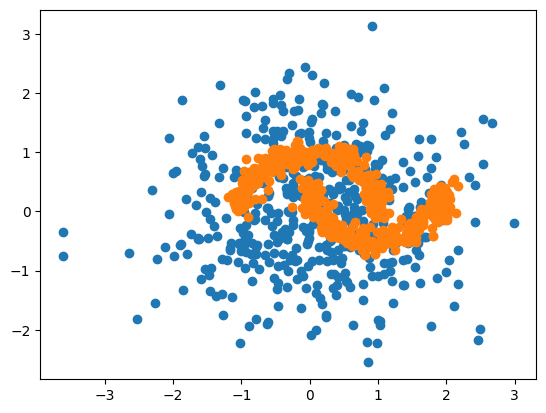

In [ ]:
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])

In [ ]:
vf

MLPUnconditionalVF(
    # attributes
    state_dim = 2
    encode_state = True
    encode_time = True
    time_features_id = None
    time_features_fn = None
    num_time_features = 256
    max_period = 1000
    time_features_kwargs = {}
    state_encoder_output_dim = 32
    time_encoder_output_dim = 16
    state_encoder_mlp_kwargs = {'hidden_dims': (32,)}
    time_encoder_mlp_kwargs = {'hidden_dims': (16,)}
    vf_decoder_mlp_kwargs = {'hidden_dims': (64, 64)}
    conditioning_id = 'concat'
    conditioning_fn = None
    conditioning_kwargs = None
    condition_encoder_input_layers = None
    condition_encoder_output_dim = 32
    condition_encoder_pooling_mode = 'mean'
    condition_encoder_pooling_kwargs = {}
    condition_encoder_output_layers_kwargs = None
    source_encoder_mlp_kwargs = None
    source_encoder_output_dim = 16
)

In [ ]:
trainer.fit(train_dataloader=train_loader, num_iterations=10_000, valid_freq=10000, prng=train_loader_key)

  0%|                                                                                                                                         | 0/10000 [00:00<?, ?it/s]

<class 'jaxlib._jax.ArrayImpl'>
<class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape int32[]
The error occurred while tracing the function vf_step_fn at /var/folders/3c/c38sh9493qq83gp8s57blqq40000gn/T/ipykernel_94417/3966832317.py:147 for jit. This value became a tracer due to JAX operations on these lines:

  operation a[35m:i32[1][39m = slice[limit_indices=(1,) start_indices=(0,) strides=(1,)] b
    from line /Users/mariia.minaeva/Desktop/sc-flow-tools/src/sc_flow/backends/jax/_utils.py:37:11 (broadcast_to_target_shape)

  operation a[35m:i32[1][39m = slice[limit_indices=(2,) start_indices=(1,) strides=(1,)] b
    from line /Users/mariia.minaeva/Desktop/sc-flow-tools/src/sc_flow/backends/jax/_utils.py:37:11 (broadcast_to_target_shape)
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError